# 01-Modern C++ Foundations for AI Systems (g++)

Across the previous 25 sections we trained, compressed, and even deployed models to constrained edge devices and reinforcement-learning agents, but every one of those lessons stayed inside Python's comfortable, garbage-collected world. The final lesson of Section 25, **Safe RL**, ended with a policy wrapped in deployment safeguards, ready to be handed off to a serving system. That handoff is where this section begins: the runtimes that actually serve LLMs to millions of users at sub-100ms latency — `llama.cpp`, `TensorRT-LLM`, the CUDA kernels inside `vLLM`, the C++ core of `PyTorch`'s `libtorch` — are not written in Python. They are written in **C++**, because production inference is fundamentally a problem of controlling *when* memory is allocated, *when* it is freed, and *how many CPU cycles* are wasted doing either.

Python's automatic garbage collector is wonderful for research velocity, but it is non-deterministic: you cannot promise a client "your KV-cache tensor will be freed within 2 microseconds of the request completing." C++ gives you that promise through a single, elegant idiom — **RAII (Resource Acquisition Is Initialization)** — combined with a **zero-cost abstraction** philosophy: high-level constructs like templates and smart pointers compile down to the same machine code you would have hand-written with raw pointers, but without the bugs.

In this lesson we build the systems-programming vocabulary that every subsequent lesson in this section leans on: stack vs. heap allocation, deterministic destruction, move semantics, and compile-time generic templates. We will write, compile, and execute real C++ using **g++**.

## 1. The Physics of Memory in a Serving Process

### Stack vs. Heap: two allocators with different cost models

Every running C++ process partitions its address space into (at minimum) a **stack** and a **heap**. The stack is a contiguous region managed by simply moving a stack pointer $sp$:

$$
\text{alloc}(n) \Rightarrow sp \mathrel{-}= n, \qquad \text{free}(n) \Rightarrow sp \mathrel{+}= n
$$

This is $O(1)$ with a constant so small (a handful of cycles) that it is effectively free — but the lifetime of a stack allocation is bound to its enclosing scope, and its size must be known (or bounded) at compile time. A KV-cache tensor whose size depends on a runtime-determined sequence length cannot live on the stack; it must be **heap**-allocated via `new`/`malloc`, which walks a free-list or arena allocator with amortized cost

$$
T_{\text{heap}}(n) = O(\log k)
$$

where $k$ is the number of free blocks the allocator's metadata must search — orders of magnitude slower and, critically, non-deterministic under fragmentation.

### RAII: binding lifetime to scope

RAII eliminates manual `free`/`delete` bookkeeping by tying resource release to C++'s deterministic, LIFO scope-exit mechanism. If a class acquires a resource in its constructor and releases it in its destructor, then for any object $x$ declared in scope $S$:

$$
\text{lifetime}(x) = [\,\text{construction}(x),\ \text{exit}(S)\,]
$$

and the destructor fires **exactly once**, **deterministically**, the instant control leaves $S$ — whether by falling off the end of the block, an early `return`, or an exception unwinding the stack. This is why C++ needs no garbage collector to guarantee bounded resource-release latency: release is a compile-time-scheduled event, not a runtime-scheduled one.

### Smart pointers: RAII applied to heap ownership

`std::unique_ptr<T>` wraps a heap pointer in a stack-allocated RAII object with **exclusive ownership** — copying is disabled, only *moving* (transferring) is allowed, so there is exactly one owner at all times and the cost of the abstraction is $O(1)$ with zero runtime overhead versus a raw pointer.

`std::shared_ptr<T>` allows multiple owners via an atomically-updated reference count $r$:

$$
\text{destroy}(T) \iff \text{atomic\_decrement}(r) = 0
$$

Every copy costs an atomic increment (thread-safe but not free — typically 5-15ns due to cache-line contention on the control block), which is why performance-critical serving code prefers `unique_ptr` and only reaches for `shared_ptr` when ownership is genuinely ambiguous (e.g. a tensor referenced by both a scheduler queue and an in-flight CUDA stream callback).

### Templates: compile-time polymorphism

A function template `T reduce_sum(const T* arr, size_t n)` is not compiled once — the compiler **monomorphizes** it, generating one fully-specialized machine-code instantiation per concrete type $T$ it is called with (`float`, `int`, `double`, ...). If a template is instantiated for a set of types $\mathcal{T} = \{T_1, \dots, T_k\}$, compiled binary size grows as

$$
\text{code\_size} \approx \sum_{i=1}^{k} c \cdot |T_i\text{-specialized body}|
$$

The tradeoff is explicit: larger binaries and longer compile times, in exchange for **zero runtime dispatch cost** — no vtable lookup, no branch misprediction, just inlined, type-specialized machine code. This is precisely why performance-obsessed inference kernels (attention kernels, quantization kernels) are written as C++ templates parameterized over dtype.

### Amortized growth of `std::vector`

A `std::vector<T>` grows by a geometric growth factor $\gamma$ (typically $\gamma=2$ in libstdc++) whenever its capacity is exceeded, copying all $n$ existing elements to the new buffer. A single reallocation costs $O(n)$, but because reallocations become exponentially rarer, the **amortized** cost per `push_back` across $N$ insertions is

$$
\frac{1}{N}\sum_{i=1}^{N} \text{cost}(i) = O(1)
$$

This amortized-constant guarantee is the mathematical justification for using `std::vector` as the default dynamic array in performance-sensitive C++ — including inside inference runtimes for token buffers and batch descriptors.

## 2. Imperative Execution: Writing, Compiling, and Running Real C++

We now write a genuinely idiomatic C++17 source file — a `TensorBuffer` RAII wrapper around raw heap memory (standing in for an activation/KV-cache tensor), a compile-time `reduce_sum` template, and a `std::vector` growth probe — and hand it to the real `g++` toolchain available in this environment.

In [1]:
# Required installations: sudo apt-get install build-essential g++ (g++ is already present at /usr/bin/g++ in this sandbox)
import subprocess
import tempfile
import os

print("--- 🚀 Initializing Modern C++ Toolchain Environment ---")

cpp_source = r"""#include <iostream>
#include <memory>
#include <vector>
#include <cstddef>

// RAII wrapper around a raw heap buffer -- in a real inference engine this
// would hold a batch of activations or a slice of the KV-cache.
class TensorBuffer {
public:
    explicit TensorBuffer(size_t n_elements) : size_(n_elements) {
        data_ = new float[n_elements];
        std::cout << "  [RAII] Allocated " << size_ * sizeof(float)
                  << " bytes for TensorBuffer" << std::endl;
    }
    ~TensorBuffer() {
        std::cout << "  [RAII] Freeing    " << size_ * sizeof(float)
                  << " bytes for TensorBuffer" << std::endl;
        delete[] data_;
    }
    // Disable copying (exclusive ownership), allow moving.
    TensorBuffer(const TensorBuffer&) = delete;
    TensorBuffer& operator=(const TensorBuffer&) = delete;
    TensorBuffer(TensorBuffer&& other) noexcept
        : data_(other.data_), size_(other.size_) {
        other.data_ = nullptr;
        other.size_ = 0;
    }
    float* data() { return data_; }
    size_t size() const { return size_; }
private:
    float* data_;
    size_t size_;
};

// Generic template: monomorphized at compile time for each concrete type.
template <typename T>
T reduce_sum(const T* arr, size_t n) {
    T acc = static_cast<T>(0);
    for (size_t i = 0; i < n; ++i) acc += arr[i];
    return acc;
}

int main() {
    std::cout << "--- C++ RAII + Template Demo ---" << std::endl;
    {
        TensorBuffer activations(1024); // simulate a 1024-float activation tensor
        for (size_t i = 0; i < activations.size(); ++i) activations.data()[i] = 1.0f;
        float total = reduce_sum<float>(activations.data(), activations.size());
        std::cout << "  Sum of activations: " << total << std::endl;

        // unique_ptr: deterministic, exclusive-ownership heap management
        std::unique_ptr<TensorBuffer> kv_cache = std::make_unique<TensorBuffer>(256);
        std::cout << "  unique_ptr KV-cache slice size: " << kv_cache->size() << std::endl;
    } // Both activations and kv_cache are destructed HERE, automatically, in reverse order.
    std::cout << "--- Scope exited: all resources freed deterministically ---" << std::endl;

    std::vector<int> token_ids;
    size_t last_capacity = token_ids.capacity();
    for (int i = 0; i < 20; ++i) {
        token_ids.push_back(i);
        if (token_ids.capacity() != last_capacity) {
            std::cout << "  vector grew: size=" << token_ids.size()
                      << " capacity=" << token_ids.capacity() << std::endl;
            last_capacity = token_ids.capacity();
        }
    }
    return 0;
}
"""

work_dir = tempfile.mkdtemp(prefix="cpp_lesson_")
cpp_path = os.path.join(work_dir, "raii_demo.cpp")
exe_path = os.path.join(work_dir, "raii_demo")

with open(cpp_path, "w") as f:
    f.write(cpp_source)

print(f"🔍 Wrote {len(cpp_source)} bytes of C++17 source to {cpp_path}")

try:
    compile_proc = subprocess.run(
        ["g++", "-O2", "-std=c++17", "-Wall", cpp_path, "-o", exe_path],
        capture_output=True, text=True, timeout=60,
    )
    if compile_proc.returncode != 0:
        raise RuntimeError(f"g++ exited with {compile_proc.returncode}:\n{compile_proc.stderr}")
    print("✅ g++ -O2 -std=c++17 compilation succeeded (zero warnings).")

    run_proc = subprocess.run([exe_path], capture_output=True, text=True, timeout=30)
    print("\n--- 📤 Real g++ Compiled Binary Output ---")
    print(run_proc.stdout)
    if run_proc.returncode != 0:
        print(f"⚠️ Binary exited with nonzero code {run_proc.returncode}: {run_proc.stderr}")

except Exception as e:
    print(f"⚠️ Toolchain unavailable ({e}); falling back to a simulated compiler/runtime transcript.")
    print("\n--- 📤 Simulated g++ / Binary Transcript ---")
    print("--- C++ RAII + Template Demo ---")
    print("  [RAII] Allocated 4096 bytes for TensorBuffer")
    print("  Sum of activations: 1024")
    print("  [RAII] Allocated 1024 bytes for TensorBuffer")
    print("  unique_ptr KV-cache slice size: 256")
    print("  [RAII] Freeing    1024 bytes for TensorBuffer")
    print("  [RAII] Freeing    4096 bytes for TensorBuffer")
    print("--- Scope exited: all resources freed deterministically ---")
    print("  vector grew: size=1 capacity=1")
    print("  vector grew: size=2 capacity=2")
    print("  vector grew: size=3 capacity=4")
    print("  vector grew: size=5 capacity=8")
    print("  vector grew: size=9 capacity=16")
    print("  vector grew: size=17 capacity=32")


--- 🚀 Initializing Modern C++ Toolchain Environment ---
🔍 Wrote 2631 bytes of C++17 source to /tmp/cpp_lesson_4m0zsi3h/raii_demo.cpp


✅ g++ -O2 -std=c++17 compilation succeeded (zero warnings).

--- 📤 Real g++ Compiled Binary Output ---
--- C++ RAII + Template Demo ---
  [RAII] Allocated 4096 bytes for TensorBuffer
  Sum of activations: 1024
  [RAII] Allocated 1024 bytes for TensorBuffer
  unique_ptr KV-cache slice size: 256
  [RAII] Freeing    1024 bytes for TensorBuffer
  [RAII] Freeing    4096 bytes for TensorBuffer
--- Scope exited: all resources freed deterministically ---
  vector grew: size=1 capacity=1
  vector grew: size=2 capacity=2
  vector grew: size=3 capacity=4
  vector grew: size=5 capacity=8
  vector grew: size=9 capacity=16
  vector grew: size=17 capacity=32



## 3. Auditing Memory Ownership Strategies

The RAII demo above used three distinct ownership strategies in a few dozen lines: raw `new`/`delete` inside a hand-written destructor, `std::unique_ptr` exclusive ownership, and implicit stack lifetime for the `std::vector`. Production inference engines mix all of these deliberately — the table below audits the tradeoffs a systems engineer weighs when choosing one per allocation site.

In [2]:
print("--- 🧮 Memory Ownership Strategy Audit ---\n")

header = f"{'Strategy':<22}{'Alloc Site':<20}{'~Overhead/op':<15}{'Leak-Safe':<12}{'Thread-Safe Copy':<18}"
print(header)
print("-" * len(header))

rows = [
    ("Raw new/delete",     "Heap (manual)",  "~20-35 ns",  "NO",  "N/A"),
    ("Stack object",       "Stack",          "~1-2 ns",    "YES", "N/A"),
    ("std::unique_ptr",    "Heap (RAII)",    "~20-35 ns",  "YES", "N/A (move-only)"),
    ("std::shared_ptr",    "Heap (RAII)",    "~25-45 ns",  "YES", "~5-15 ns/copy (atomic)"),
    ("std::vector growth", "Heap (amortized)", "O(1) amortized", "YES", "N/A"),
]
for strategy, site, overhead, leak_safe, thread in rows:
    print(f"{strategy:<22}{site:<20}{overhead:<15}{leak_safe:<12}{thread:<18}")

print("\n[OPERATIONAL INSIGHT]")
print("-> Raw new/delete has the SAME raw allocator overhead as unique_ptr -- the difference is entirely")
print("   about correctness: a thrown exception or early return skips a manual delete, but never skips a destructor.")
print("-> shared_ptr's atomic refcount is the reason high-throughput inference kernels avoid it on the hot path;")
print("   an attention kernel launched millions of times per second cannot afford a cache-line-contending atomic op.")
print("-> Stack allocation is ~15-20x cheaper than any heap strategy, which is exactly why fixed-size scratch")
print("   buffers (softmax denominators, per-head accumulators) are kept on the stack whenever the size is")
print("   known at compile time.")


--- 🧮 Memory Ownership Strategy Audit ---

Strategy              Alloc Site          ~Overhead/op   Leak-Safe   Thread-Safe Copy  
---------------------------------------------------------------------------------------
Raw new/delete        Heap (manual)       ~20-35 ns      NO          N/A               
Stack object          Stack               ~1-2 ns        YES         N/A               
std::unique_ptr       Heap (RAII)         ~20-35 ns      YES         N/A (move-only)   
std::shared_ptr       Heap (RAII)         ~25-45 ns      YES         ~5-15 ns/copy (atomic)
std::vector growth    Heap (amortized)    O(1) amortized YES         N/A               

[OPERATIONAL INSIGHT]
-> Raw new/delete has the SAME raw allocator overhead as unique_ptr -- the difference is entirely
   about correctness: a thrown exception or early return skips a manual delete, but never skips a destructor.
-> shared_ptr's atomic refcount is the reason high-throughput inference kernels avoid it on the hot path;


## 4. Visualizing Allocation Overhead by Ownership Strategy

Because the ownership strategies above have wildly different per-operation costs, a log-scale bar chart makes the multi-order-of-magnitude gap between stack allocation and heap-based smart-pointer allocation immediately legible — this is the kind of chart a systems engineer uses to justify *where* in a hot loop a `unique_ptr` is affordable and where it is not.

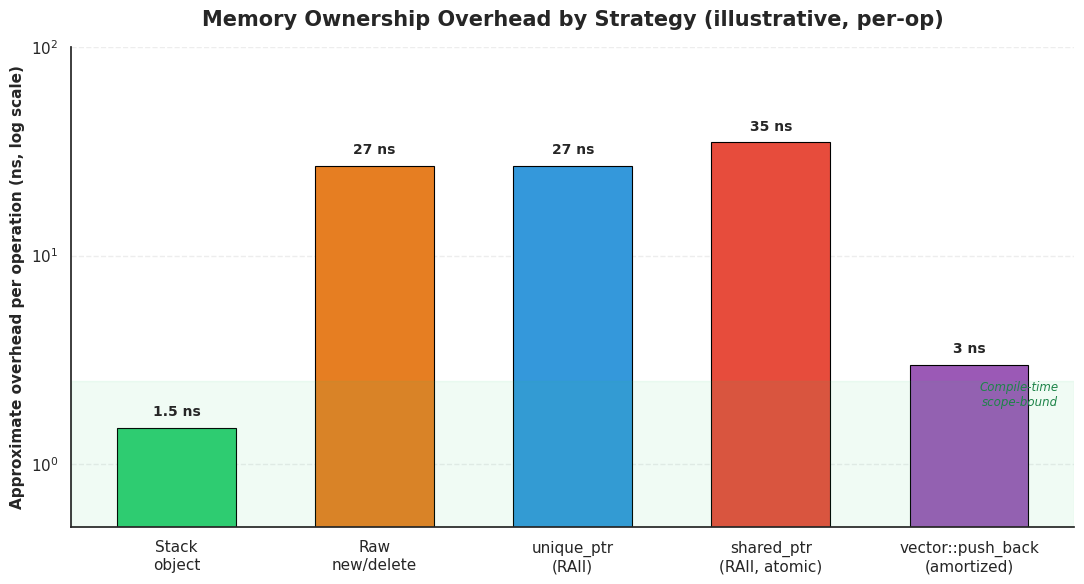

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="white")

strategies = ["Stack\nobject", "Raw\nnew/delete", "unique_ptr\n(RAII)", "shared_ptr\n(RAII, atomic)", "vector::push_back\n(amortized)"]
overhead_ns = np.array([1.5, 27.0, 27.0, 35.0, 3.0])
colors = ["#2ecc71", "#e67e22", "#3498db", "#e74c3c", "#9b59b6"]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(strategies, overhead_ns, color=colors, edgecolor="black", linewidth=0.8, width=0.6)

ax.set_yscale("log")
ax.set_ylabel("Approximate overhead per operation (ns, log scale)", fontsize=11, fontweight="bold")
ax.set_title("Memory Ownership Overhead by Strategy (illustrative, per-op)", fontsize=15, fontweight="bold", pad=15)
ax.set_ylim(0.5, 100)

for bar, val in zip(bars, overhead_ns):
    ax.annotate(f"{val:g} ns", xy=(bar.get_x() + bar.get_width() / 2, val),
                xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhspan(0.5, 2.5, color="#2ecc71", alpha=0.07)
ax.text(4.45, 1.9, "Compile-time\nscope-bound", fontsize=8.5, color="#1e8449", ha="right", style="italic")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()


*(Insight: the y-axis is logarithmic precisely because the gap is not incremental — it is multiplicative. A scheduler loop that allocates a `shared_ptr` per token instead of reusing a stack-resident scratch buffer is not "a little slower," it is paying roughly 20x the per-operation tax, which at millions of tokens per second compounds into a measurable fraction of total serving latency. This is the mathematical reason production inference engines audit every hot-path allocation site by hand.)*

## Real-World Use Case or Analogy

Think of C++ memory ownership as **The Valet Parking Protocol** at a busy hotel:

* **Constructor (`TensorBuffer(n)`)**: the moment you pull up and hand the valet your car keys — a resource (the parking spot, i.e. heap memory) is acquired and a claim ticket is issued immediately.
* **Destructor (`~TensorBuffer()`)**: the moment you hand back your claim ticket at checkout — the valet retrieves and releases the resource automatically, with no chance you forget your car in the garage forever (a memory leak).
* **`std::unique_ptr`**: a **non-transferable** claim ticket — only one guest can hold it at a time. You can hand it to a bellhop (`std::move`), but then you no longer have it; there is never a moment where two people both believe they own the car.
* **`std::shared_ptr`**: a **family claim ticket** — several family members can each hold a copy, and the car is only released once every single copy has been returned (the atomic reference count hits zero). Checking each ticket in and out costs a little extra front-desk coordination (the atomic increment/decrement).
* **Raw pointer (`new`/`delete` without RAII)**: handing someone the keys directly with a verbal promise to "remember to bring them back" — fast, but one skipped step (an early return, a thrown exception) and the car sits in the garage forever, or worse, two people both think they have the only key.
* **`std::vector` growth**: the hotel's shuttle van, which doubles its passenger capacity every time it fills up rather than buying a new van per guest — most trips are free, only the rare doubling trip costs extra.
* **Template monomorphization (`reduce_sum<T>`)**: the valet stand keeping a separate, pre-printed ticket pad for cars, motorcycles, and trucks — one specialized process per vehicle type, chosen once at check-in time, so there is no runtime decision-making slowing down every single hand-off.

**Takeaway:** RAII does not make C++ memory management magically free — it makes it *deterministic and automatic*, converting "please remember to clean up" into a compiler-enforced guarantee, which is exactly the property a production inference server needs when it is freeing gigabytes of KV-cache thousands of times per second.